[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddumu/dourado-minguell-eml-mia-um-p1/blob/main/k_brazos/epsilon_greedy_binomial_dist_experiment.ipynb)

# Estudio del bandido de k-brazos mediante el algoritmo $\epsilon$-Greedy con distribución binomial

En este notebook se ejecuta y comenta la ejecución del experimento del bandido de k-brazos mediante el algoritmo $\epsilon$-greedy con brazos cuya recompensa viene dada por una función de distribución binomial.

In [ ]:
!git clone https://github.com/ddumu/dourado-minguell-eml-mia-um-p1
%cd dourado-minguell-eml-mia-um-p1/k_brazos/
%ls

## Constantes

In [1]:
SEED = 42

K = 10
RUNS = 1000
STEPS = 20_000

SAVE_PLOTS_PATH = "plots/epsilon_greedy_binomial_dist"

## Librerías

In [ ]:
import sys
import random
import numpy as np

sys.path.append('./src')

from arms import ArmBinomial, Bandit
from experiment import run_experiment
from algorithms import EpsilonGreedy
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

['C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\python312.zip', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\DLLs', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv', '', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv\\Lib\\site-packages', './src']


## Reproducibilidad

In [3]:
random.seed(SEED)
np.random.seed(SEED)

Asegurar que la generación de números aleatorios es igual para todos los experimentos.

## Experimentación

Se ejecuta la experimentación del problema del bandido de k-brazos durante el número de pasos y ejecuciones definido en las constantes. Posteriormente, se realiza el pertinente estudio de resultados mediantes las gráficas de recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas por brazo.

In [4]:
# Creación del bandido de k-brazos
bandit = Bandit(arms=ArmBinomial.generate_arms(K))
optimal_arm = bandit.optimal_arm

print(bandit)
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

Bandit with 10 arms: ArmBinomial (n=100, p=0.39), ArmBinomial (n=100, p=0.91), ArmBinomial (n=100, p=0.71), ArmBinomial (n=100, p=0.19), ArmBinomial (n=100, p=0.59), ArmBinomial (n=100, p=0.1), ArmBinomial (n=100, p=0.83), ArmBinomial (n=100, p=0.69), ArmBinomial (n=100, p=0.07), ArmBinomial (n=100, p=0.92)
Optimal arm: 10 with expected reward=0.92


Para le experimentación, se va emplear un bandido de 10 brazos. Para este caso reproducible, el brazo óptimo es el número 10 con una recompensa media esperada de 0.92. Se van a comparar los resultados con distintos valores para epsilon:
 - $\epsilon = 0.0$
 - $\epsilon = 0.01$
 - $\epsilon = 0.1$
 - $\epsilon = 0.5$

In [5]:
# Definir los algoritmos greedy con diferente epsilon
algorithms_greedy = [
    EpsilonGreedy(k=K, epsilon=0),
    EpsilonGreedy(k=K, epsilon=0.01),
    EpsilonGreedy(k=K, epsilon=0.1),
    EpsilonGreedy(k=K, epsilon=0.5)
]

# Ejecutar el experimento
rewards_greedy, optimal_selections_greedy, regret_accumulated_greedy, arm_stats_greedy = run_experiment(bandit, algorithms_greedy, STEPS, RUNS)

Ya se han definido los algoritmos y ejecutada la experimentación. A continuación, se van a comentar los resultados obtenidos mediante las correspondientes gráficas.

#### Recompensas promedio

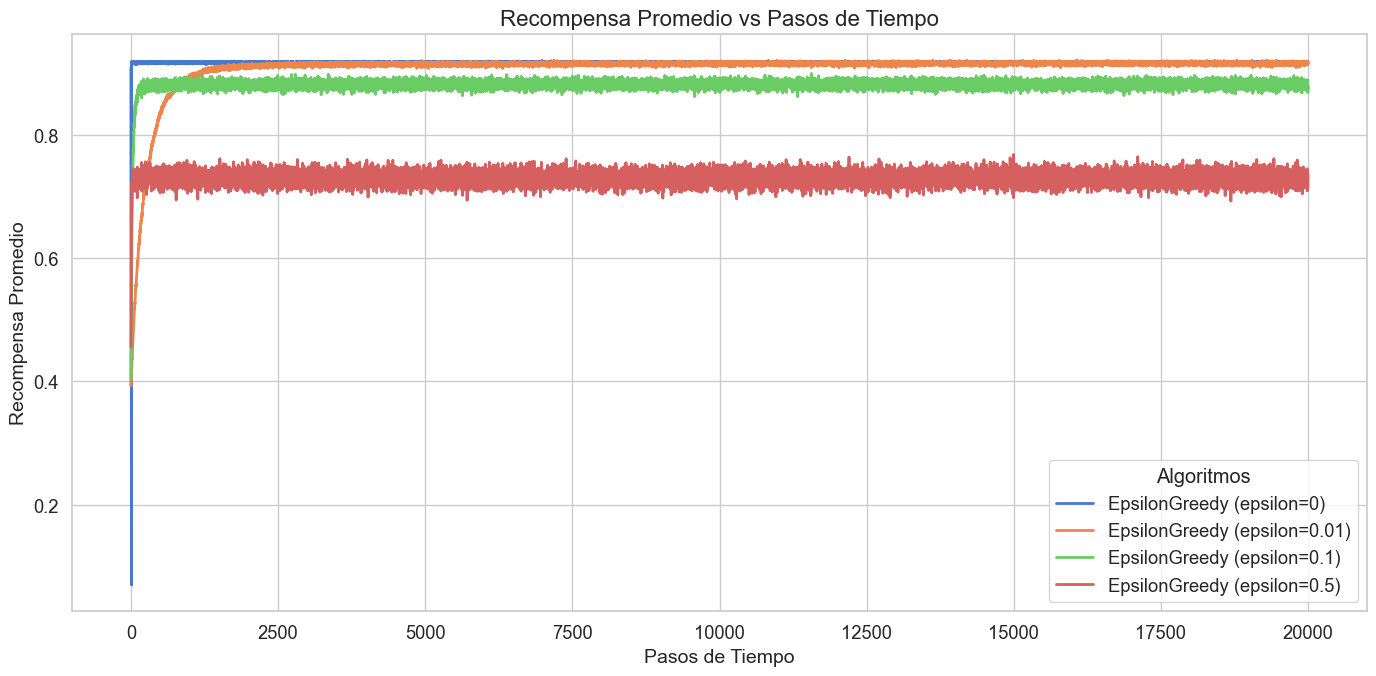

In [6]:
plot_average_rewards(STEPS, rewards_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

En este gráfico se muestra como a lo largo de los pasos hay dos configuraciones claramente superiores: epsilon=0 y epsilon=0.01. Los algoritmos con mayor exploración quedan desbancados en los primeros 1000 pasos aproximadamente. Resulta curisoso como la versión con epsilon=0 que no explora obtiene resultados muy similares a epsilon=0.01. Si nos fijamos en las probabilidades de los brazos, el segundo tiene tan solo 0.1 menos de probabilidad de éxito, por tanto, esto le da una gran ventaja al algoritmo explotador, pues tiene mayor probabilidad de encontrar un brazo óptimo o insignificantemente peor que el óptimo en el primer barrido.

#### Selecciones óptimas

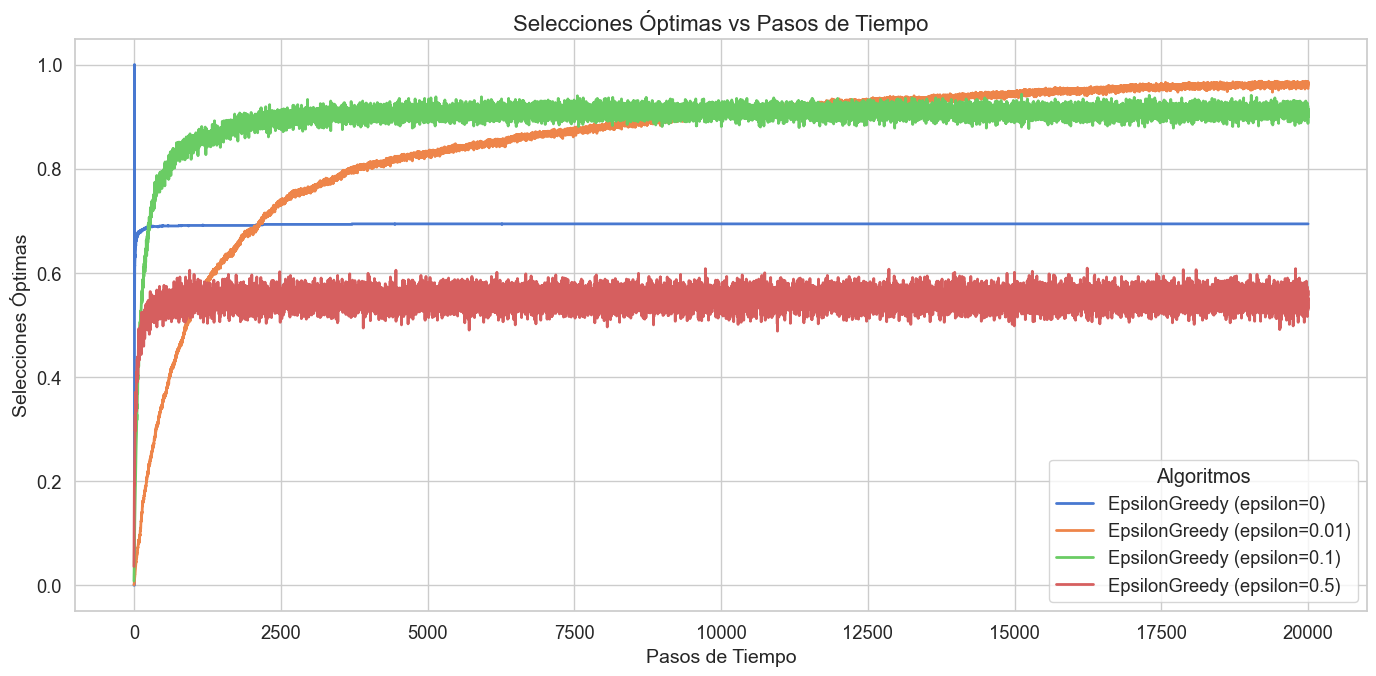

In [7]:
plot_optimal_selections(STEPS, optimal_selections_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

La gráfica de selecciones óptimas confirma la teoría sobre el algoritmo explotador consiguiendo excelente resultados. Vemos como con eplison=0 tan solo elige la selección óptima alrededor de un 70% de las veces, por lo que el otro 30%, descontando las selecciones incorrectas, estará eligiendo el segundo brazo. Se podrá comprobar posteriormente con las estadísticas por brazo.

#### Arrepentimiento

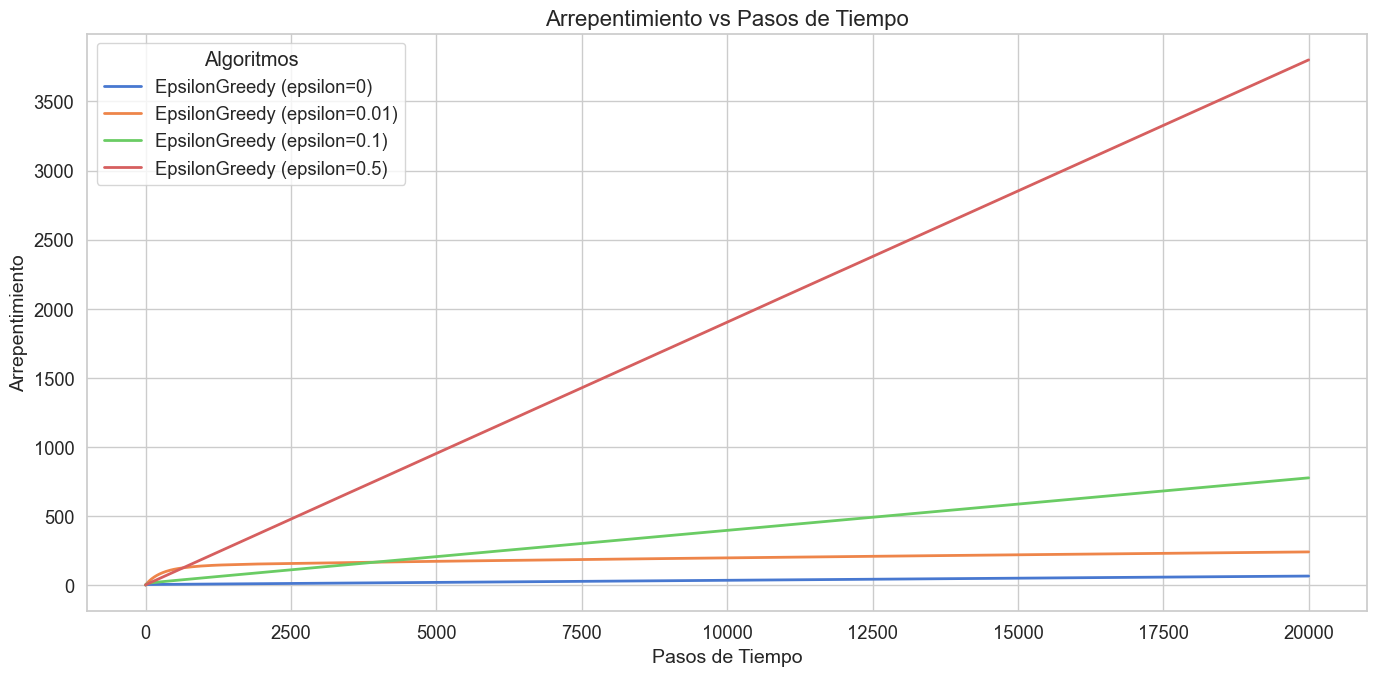

In [8]:
plot_regret(STEPS, regret_accumulated_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

Comparando desde la gráfica de arrepentimiento acumulado continúan estando igualados los epsilon=0 y epsilon=0.01. Con los pasos estudiados, la versión explotadora tiene menor arrepentimiento acumulado. Viendo la tendencia parece que en un horizonte lejano, la versión con epsilon=0 podría llegar a superar a la otra en arrepentimiento acumulado en algún momento, pero haría falta una experimentación más exhaustiva para corroborarlo.

#### Estadísticas por brazo

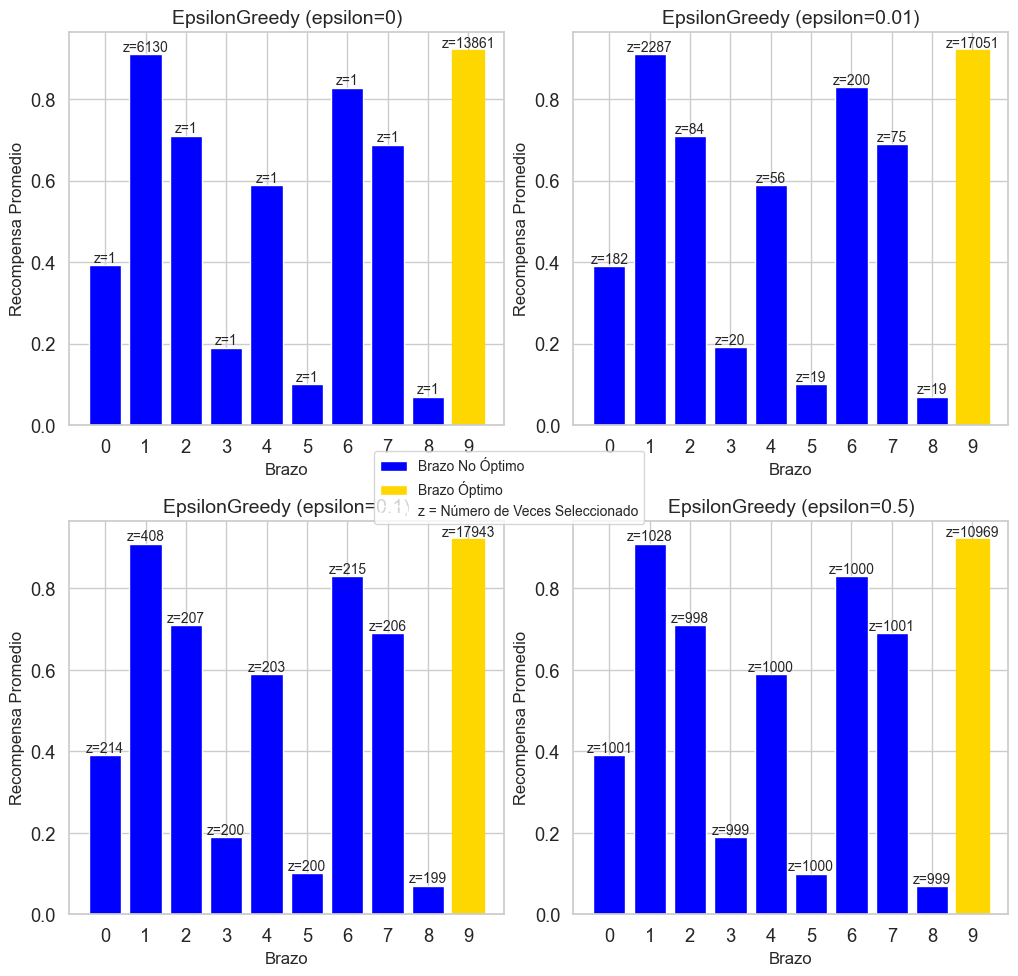

In [9]:
plot_arm_statistics(arm_stats_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

Gracias a las estadísticas por brazo, se puede comprobar que el algoritmo con epsilon=0, elige los 2 brazos más óptimos en la mayoría de las ejecuciones. También ocurre para epsilon=0.01, pero en un porcentaje menor de las ocasiones por exploración. Ver que todos los algoritmos seleccionan el brazo óptimo el mayor número de veces pese a tener una distribución de recompensas tan similar al segundo demuestra que el algoritmo $\epsilon$-greedy es eficaz en su cometido.

## Conclusiones

Aunque los resultados del algoritmo $\epsilon$-Greedy con epsilon=0 y epsilon=0.01 hayan sido similares, tener un algoritmo 100% explotador pierde la ventaja de tener una componente exploratoria con la probabilidad $\epsilon$, por lo que en algunas ejecuciones nunca podría encontrar el brazo óptimo. Nuevamente, igual que con la distribución normal, una probabilidad de exploración menor tarda más en alcanzar resultados con poco arrepentimiento, pero luego es capaz de explotarlo más a lo largo del tiempo.